In [1]:
!pip install tensorflow

##  Cell 1: GPU Check + Mount Google Drive

In [2]:
import subprocess
import os
import tensorflow as tf

print(f"TensorFlow version: {tf.__version__}")


from google.colab import drive
import os

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')
else:
    print("Drive already mounted.")

# Create the ubuzima_data folder in your Drive
BASE_DIR    = '/content/drive/MyDrive/ubuzima_data'
MODEL_DIR   = '/content/drive/MyDrive/ubuzima_model'
RESULTS_DIR = '/content/drive/MyDrive/ubuzima_results'

os.makedirs(BASE_DIR,    exist_ok=True)
os.makedirs(MODEL_DIR,   exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"\n Google Drive mounted.")
print(f"   Data folder:    {BASE_DIR}")
print(f"   Model folder:   {MODEL_DIR}")
print(f"   Results folder: {RESULTS_DIR}")

TensorFlow version: 2.19.0
Mounted at /content/drive

 Google Drive mounted.
   Data folder:    /content/drive/MyDrive/ubuzima_data
   Model folder:   /content/drive/MyDrive/ubuzima_model
   Results folder: /content/drive/MyDrive/ubuzima_results




##  Cell 2: Downloading All Datasets


In [4]:
print(" Upload your kaggle.json file:")
from google.colab import files
uploaded = files.upload()

import os, shutil
os.makedirs('/root/.kaggle', exist_ok=True)
shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print(" Kaggle configured.")

!pip install -q kaggle

WORK_DIR = '/content/ubuzima_work'
os.makedirs(WORK_DIR, exist_ok=True)
os.chdir(WORK_DIR)

print("\n 1/5  Chest X-Ray Pneumonia (Normal + Pneumonia, ~1.2 GB)...")
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia --unzip -q
print(" Done.")

print("\n  2/5  Shenzhen TB dataset (~80 MB)...")
!kaggle datasets download -d raddar/tuberculosis-chest-xrays-shenzhen --unzip -q
print(" Done.")

print("\n  3/5  Montgomery TB dataset (~15 MB)...")
!kaggle datasets download -d raddar/tuberculosis-chest-xrays-montgomery --unzip -q
print(" Done.")

print("\n  4/5  TBX11K — extra TB images (~3 GB, takes ~5 min)...")
!kaggle datasets download -d usmanshams/tbx-11 --unzip -q
print(" Done.")

# print("\n  5/5  NIH ChestX-ray14 sample (for Unknown class)...")
# !kaggle datasets download -d nih-chest-xrays/data --unzip -q -f Data_Entry_2017.csv
# !kaggle datasets download -d nih-chest-xrays/data --unzip -q -f images_001.zip
# print(" Done.")

print("\n All datasets downloaded. Contents of work dir:")
for item in sorted(os.listdir(WORK_DIR)):
    print(f"  {item}")


 Upload your kaggle.json file:


Saving kaggle.json to kaggle.json
 Kaggle configured.

 1/5  Chest X-Ray Pneumonia (Normal + Pneumonia, ~1.2 GB)...
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
 Done.

  2/5  Shenzhen TB dataset (~80 MB)...
Dataset URL: https://www.kaggle.com/datasets/raddar/tuberculosis-chest-xrays-shenzhen
License(s): unknown
 Done.

  3/5  Montgomery TB dataset (~15 MB)...
Dataset URL: https://www.kaggle.com/datasets/raddar/tuberculosis-chest-xrays-montgomery
License(s): unknown
 Done.

  4/5  TBX11K — extra TB images (~3 GB, takes ~5 min)...
Dataset URL: https://www.kaggle.com/datasets/usmanshams/tbx-11
License(s): unknown
 Done.

 All datasets downloaded. Contents of work dir:
  TBX11K
  chest_xray
  images
  montgomery_metadata.csv
  shenzhen_metadata.csv


---
##  Cell 3: Organising All Images into Class Folders


In [5]:
from pathlib import Path
from PIL import Image
from tqdm.notebook import tqdm
import os, random
random.seed(42)

CLASSES = ['Normal', 'Pneumonia', 'Tuberculosis', 'Unknown']
for cls in CLASSES:
    os.makedirs(os.path.join(BASE_DIR, cls), exist_ok=True)

def copy_as_rgb(src, dst):
    try:
        Image.open(src).convert('RGB').save(dst)
        return True
    except:
        return False

# ── 1. Chest X-Ray Pneumonia ──────────────────────────────────
print("1. Processing Chest X-Ray Pneumonia...")
n_cxr = p_cxr = 0
for split in ['train', 'val', 'test']:
    for cls_src, cls_dst in [('NORMAL', 'Normal'), ('PNEUMONIA', 'Pneumonia')]:
        src_dir = Path(WORK_DIR) / 'chest_xray' / split / cls_src
        if not src_dir.exists(): continue
        for f in src_dir.glob('*.*'):
            if f.suffix.lower() not in ['.png','.jpg','.jpeg']: continue
            dst = os.path.join(BASE_DIR, cls_dst, f'cxr_{split}_{f.name}')
            if copy_as_rgb(f, dst):
                if cls_dst == 'Normal': n_cxr += 1
                else: p_cxr += 1
print(f"   Normal: {n_cxr:,}  |  Pneumonia: {p_cxr:,}")

# ── 2. Shenzhen + Montgomery TB ───────────────────────────────
print("\n2. Processing Shenzhen + Montgomery...")
shen = mont = 0
images_dir = Path(WORK_DIR) / 'images' / 'images'
all_imgs = list(images_dir.glob('*.png')) + list(images_dir.glob('*.jpg'))
print(f"   Found {len(all_imgs)} images")
for f in tqdm(all_imgs, desc='TB datasets', leave=False):
    name = f.name
    if name.startswith('CHNCXR'):
        try:
            label = name.replace('.png','').replace('.jpg','').split('_')[-1]
            cls = 'Normal' if label == '0' else 'Tuberculosis'
            if copy_as_rgb(f, os.path.join(BASE_DIR, cls, f'shenzhen_{name}')): shen += 1
        except: pass
    elif name.startswith('MCUCXR') or name.startswith('MCU'):
        try:
            label = name.replace('.png','').replace('.jpg','').split('_')[-1]
            cls = 'Normal' if label == '0' else 'Tuberculosis'
            if copy_as_rgb(f, os.path.join(BASE_DIR, cls, f'montgomery_{name}')): mont += 1
        except: pass
print(f"   Shenzhen: {shen}  |  Montgomery: {mont}")

# ── 3. TBX11K (capped to save time) ──────────────────────────
print("\n3. Processing TBX11K (capped at 2,000 per folder)...")
tbx_root = Path(WORK_DIR) / 'TBX11K'
tbx_tb = tbx_normal = 0
CAP = 2000
for folder, label in [('imgs/tb', 'Tuberculosis'),
                       ('imgs/sick', 'Tuberculosis'),
                       ('imgs/health', 'Normal')]:
    src = tbx_root / folder
    if not src.exists():
        print(f"   Skipping {folder} (not found)")
        continue
    files = (list(src.glob('*.jpg')) + list(src.glob('*.png')))[:CAP]
    for f in tqdm(files, leave=False, desc=folder):
        dst = os.path.join(BASE_DIR, label, f'tbx_{folder.replace("/","_")}_{f.name}')
        if copy_as_rgb(f, dst):
            if label == 'Tuberculosis': tbx_tb += 1
            else: tbx_normal += 1
print(f"   TBX11K TB: {tbx_tb:,}  |  TBX11K Normal: {tbx_normal:,}")

# ── 4. Unknown class (NO NIH CSV needed) ─────────────────────
print("\n4. Building Unknown class...")
u_count = 0
UNKNOWN_CAP = 2000

# TBX11K ambiguous folders
for folder in ['imgs/sick_and_tb', 'imgs/tb_with_eff', 'imgs/uncertain']:
    src = tbx_root / folder
    if not src.exists(): continue
    files = (list(src.glob('*.jpg')) + list(src.glob('*.png')))[:UNKNOWN_CAP//3]
    for f in tqdm(files, leave=False, desc=f'Unknown {folder}'):
        if u_count >= UNKNOWN_CAP: break
        dst = os.path.join(BASE_DIR, 'Unknown',
                           f'unk_{folder.replace("/","_")}_{f.name}')
        if copy_as_rgb(f, dst): u_count += 1

# Bacterial pneumonia — ambiguous presentation
bact_dir = Path(WORK_DIR) / 'chest_xray' / 'train' / 'PNEUMONIA'
if bact_dir.exists() and u_count < UNKNOWN_CAP:
    bact_files = list(bact_dir.glob('*bacteria*'))
    random.shuffle(bact_files)
    for f in tqdm(bact_files[:800], leave=False, desc='Unknown bacteria'):
        if u_count >= UNKNOWN_CAP: break
        dst = os.path.join(BASE_DIR, 'Unknown', f'unk_bact_{f.name}')
        if copy_as_rgb(f, dst): u_count += 1

print(f"   Unknown images: {u_count:,}")

# Final count
print("FINAL DATASET COUNT")

grand = 0
for cls in CLASSES:
    n = len([f for f in os.listdir(os.path.join(BASE_DIR, cls))
             if f.lower().endswith(('.png','.jpg','.jpeg'))])
    grand += n
    print(f"  {cls:15s}: {n:,}")
print(f"  {'TOTAL':15s}: {grand:,}")


1. Processing Chest X-Ray Pneumonia...
   Normal: 1,583  |  Pneumonia: 4,273

2. Processing Shenzhen + Montgomery...
   Found 800 images


TB datasets:   0%|          | 0/800 [00:00<?, ?it/s]

   Shenzhen: 662  |  Montgomery: 138

3. Processing TBX11K (capped at 2,000 per folder)...


imgs/tb:   0%|          | 0/800 [00:00<?, ?it/s]

imgs/sick:   0%|          | 0/2000 [00:00<?, ?it/s]

imgs/health:   0%|          | 0/2000 [00:00<?, ?it/s]

   TBX11K TB: 2,800  |  TBX11K Normal: 2,000

4. Building Unknown class...


Unknown bacteria:   0%|          | 0/800 [00:00<?, ?it/s]

   Unknown images: 800
FINAL DATASET COUNT
  Normal         : 9,195
  Pneumonia      : 7,152
  Tuberculosis   : 12,745
  Unknown        : 4,520
  TOTAL          : 33,612


Total images: 33,612
  Normal         : 9,195  (27.4%)
  Pneumonia      : 7,152  (21.3%)
  Tuberculosis   : 12,745  (37.9%)
  Unknown        : 4,520  (13.4%)


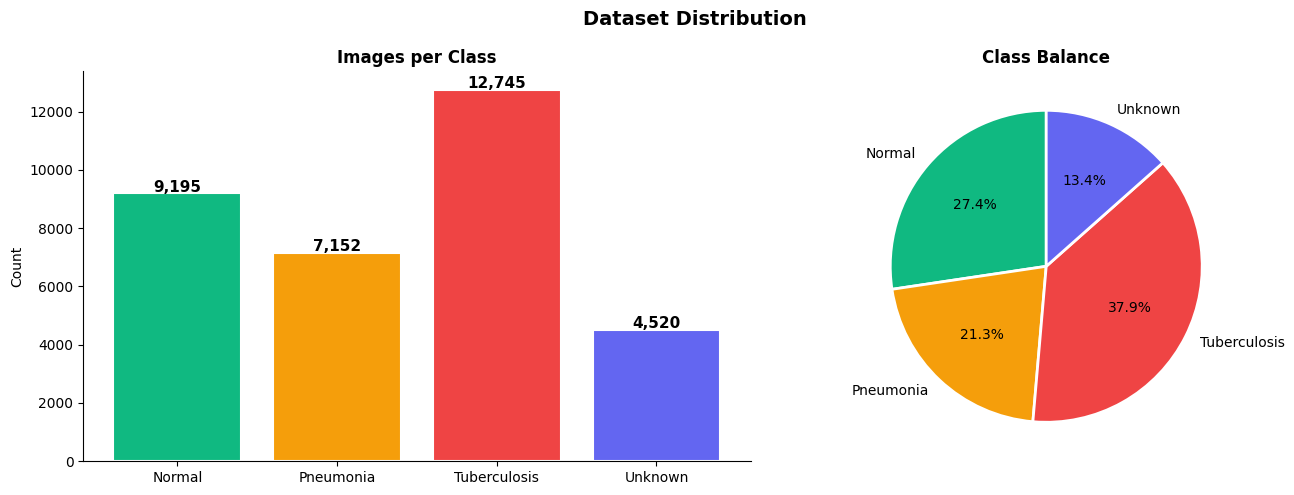

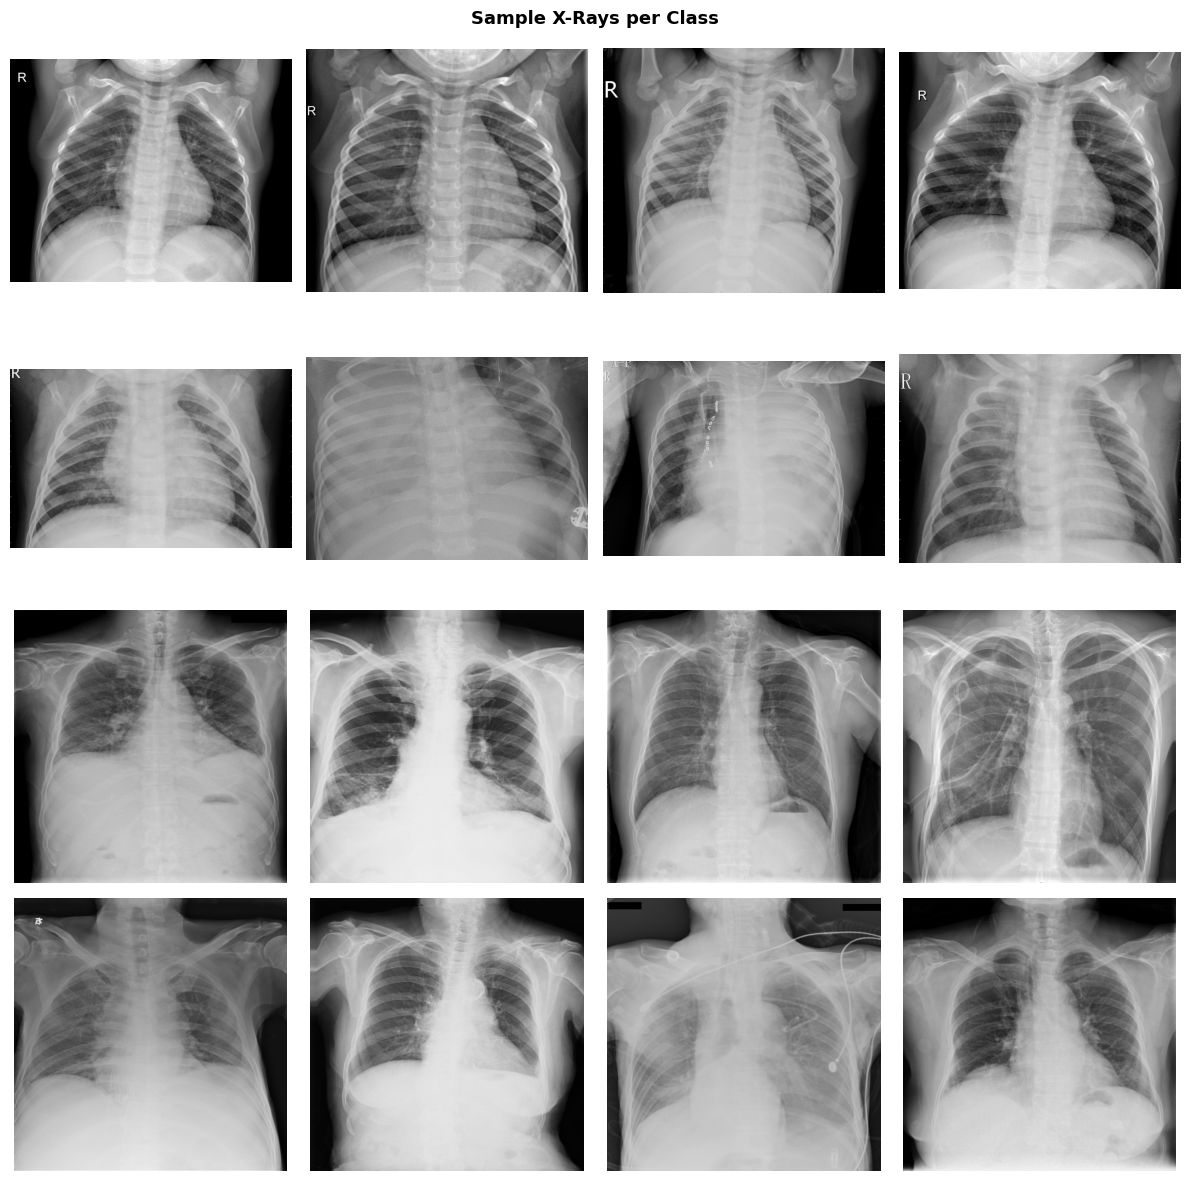

 Visualisation complete.


In [6]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from PIL import Image
import random, os

CLASS_COLORS = {
    'Normal':       '#10b981',
    'Pneumonia':    '#f59e0b',
    'Tuberculosis': '#ef4444',
    'Unknown':      '#6366f1',
}
CLASSES = ['Normal', 'Pneumonia', 'Tuberculosis', 'Unknown']

# Count images per class
counts, paths = {}, {}
for cls in CLASSES:
    cls_dir = os.path.join(BASE_DIR, cls)
    files = [os.path.join(cls_dir, f) for f in os.listdir(cls_dir)
             if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    counts[cls] = len(files)
    paths[cls]  = files

total = sum(counts.values())
print(f"Total images: {total:,}")
for cls in CLASSES:
    pct = counts[cls] / total * 100
    print(f"  {cls:15s}: {counts[cls]:,}  ({pct:.1f}%)")

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dataset Distribution', fontsize=14, fontweight='bold')

ax = axes[0]
bars = ax.bar(CLASSES, [counts[c] for c in CLASSES],
              color=[CLASS_COLORS[c] for c in CLASSES], edgecolor='white', linewidth=1.5)
for bar, cls in zip(bars, CLASSES):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f"{counts[cls]:,}", ha='center', fontweight='bold', fontsize=11)
ax.set_title('Images per Class', fontweight='bold')
ax.set_ylabel('Count')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Pie chart
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    [counts[c] for c in CLASSES],
    labels=CLASSES, colors=[CLASS_COLORS[c] for c in CLASSES],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax2.set_title('Class Balance', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig1_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

# Sample images grid
fig2, axes2 = plt.subplots(4, 4, figsize=(12, 12))
fig2.suptitle('Sample X-Rays per Class', fontsize=13, fontweight='bold')
for row, cls in enumerate(CLASSES):
    samples = random.sample(paths[cls][:50], min(4, len(paths[cls])))
    for col, img_path in enumerate(samples):
        ax = axes2[row][col]
        ax.imshow(Image.open(img_path).convert('RGB'), cmap='gray')
        if col == 0:
            ax.set_ylabel(cls, fontweight='bold', color=CLASS_COLORS[cls], fontsize=11)
        ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig2_samples.png'), dpi=150, bbox_inches='tight')
plt.show()
print(" Visualisation complete.")

In [7]:
# TBX11K is now downloaded in Cell 2 above.
# This cell is kept for reference only — skip it.
print(" TBX11K was already downloaded in Cell 2. Proceed to Cell 3 (organise).")


 TBX11K was already downloaded in Cell 2. Proceed to Cell 3 (organise).


In [8]:
from pathlib import Path
from PIL import Image
from tqdm.notebook import tqdm
import os

tbx_root = Path(WORK_DIR) / 'TBX11K'

# First let's see the folder structure
print("TBX11K folder structure:")
for item in tbx_root.rglob('*'):
    if item.is_dir():
        count = len(list(item.glob('*')))
        print(f"  {item.relative_to(tbx_root)}/ — {count} items")

TBX11K folder structure:
  annotations/ — 2 items
  imgs/ — 5 items
  code/ — 3 items
  lists/ — 7 items
  annotations/json/ — 10 items
  annotations/xml/ — 800 items
  imgs/health/ — 3800 items
  imgs/tb/ — 800 items
  imgs/test/ — 3302 items
  imgs/extra/ — 2 items
  imgs/sick/ — 3800 items
  imgs/extra/mc+shenzhen/ — 2 items
  imgs/extra/da+db/ — 2 items
  imgs/extra/mc+shenzhen/train/ — 200 items
  imgs/extra/mc+shenzhen/val/ — 200 items
  imgs/extra/da+db/train/ — 88 items
  imgs/extra/da+db/val/ — 88 items


In [18]:
from pathlib import Path
from PIL import Image
from tqdm.notebook import tqdm
import os

tbx_root = Path(WORK_DIR) / 'TBX11K'

def copy_as_rgb(src, dst):
    try:
        Image.open(src).convert('RGB').save(dst)
        return True
    except Exception:
        return False

tb_dir = os.path.join(BASE_DIR, 'Tuberculosis')
added = 0

# imgs/tb/ — confirmed TB positive cases
tb_folder = tbx_root / 'imgs' / 'tb'
for f in tqdm(list(tb_folder.glob('*.jpg')) + list(tb_folder.glob('*.png')),
              desc='TBX11K tb/', leave=False):
    dst = os.path.join(tb_dir, f'tbx_{f.name}')
    if copy_as_rgb(f, dst):
        added += 1

# imgs/sick/ — TB sick cases (different severity levels)
sick_folder = tbx_root / 'imgs' / 'sick'
for f in tqdm(list(sick_folder.glob('*.jpg')) + list(sick_folder.glob('*.png')),
              desc='TBX11K sick/', leave=False):
    dst = os.path.join(tb_dir, f'tbx_sick_{f.name}')
    if copy_as_rgb(f, dst):
        added += 1

print(f"TBX11K images added: {added}")

# Final recount
print("\nUPDATED DATASET COUNT")
print("="*35)
grand_total = 0
for cls in ['Normal', 'Pneumonia', 'Tuberculosis']:
    actual = len([f for f in os.listdir(os.path.join(BASE_DIR, cls))
                  if f.lower().endswith(('.png','.jpg','.jpeg'))])
    grand_total += actual
    print(f"  {cls:15s}: {actual:,}")
print(f"  {'TOTAL':15s}: {grand_total:,}")

TBX11K tb/:   0%|          | 0/800 [00:00<?, ?it/s]

TBX11K sick/:   0%|          | 0/3800 [00:00<?, ?it/s]

TBX11K images added: 4600

UPDATED DATASET COUNT
  Normal         : 9,195
  Pneumonia      : 7,152
  Tuberculosis   : 12,745
  TOTAL          : 29,092


In [20]:
# Class configuration: 4 classes
CLASSES     = ['Normal', 'Pneumonia', 'Tuberculosis', 'Unknown']
NUM_CLASSES = 4

CLASS_COLORS = {
    'Normal':       '#10b981',
    'Pneumonia':    '#f59e0b',
    'Tuberculosis': '#ef4444',
    'Unknown':      '#6366f1',
}

print(" Class configuration: 4 classes")
print(f"   {CLASSES}")
print()
print("Dataset summary (approximate after all sources):")
print("  Normal:       ~4,000  (Kaggle + Shenzhen + Montgomery + NIH)")
print("  Pneumonia:    ~5,800  (Kaggle + NIH)")
print("  Tuberculosis: ~2,500  (Shenzhen + Montgomery + TBX11K, augmented)")
print("  Unknown:      ~1,000  (NIH multi-label diseases)")
print()
print("Proceed to Cell 4 (visualisations).")


 Class configuration: 4 classes
   ['Normal', 'Pneumonia', 'Tuberculosis', 'Unknown']

Dataset summary (approximate after all sources):
  Normal:       ~4,000  (Kaggle + Shenzhen + Montgomery + NIH)
  Pneumonia:    ~5,800  (Kaggle + NIH)
  Tuberculosis: ~2,500  (Shenzhen + Montgomery + TBX11K, augmented)
  Unknown:      ~1,000  (NIH multi-label diseases)

Proceed to Cell 4 (visualisations).


In [21]:
from pathlib import Path
real_dir = Path(WORK_DIR) / 'images' / 'images'
files = list(real_dir.glob('*'))
print(f"Total files: {len(files)}")
print("First 10 filenames:")
for f in sorted(files)[:10]:
    print(f"  {f.name}")

Total files: 800
First 10 filenames:
  CHNCXR_0001_0.png
  CHNCXR_0002_0.png
  CHNCXR_0003_0.png
  CHNCXR_0004_0.png
  CHNCXR_0005_0.png
  CHNCXR_0006_0.png
  CHNCXR_0007_0.png
  CHNCXR_0008_0.png
  CHNCXR_0009_0.png
  CHNCXR_0010_0.png


---
##  Cell 4: Visualizing Data Distribution


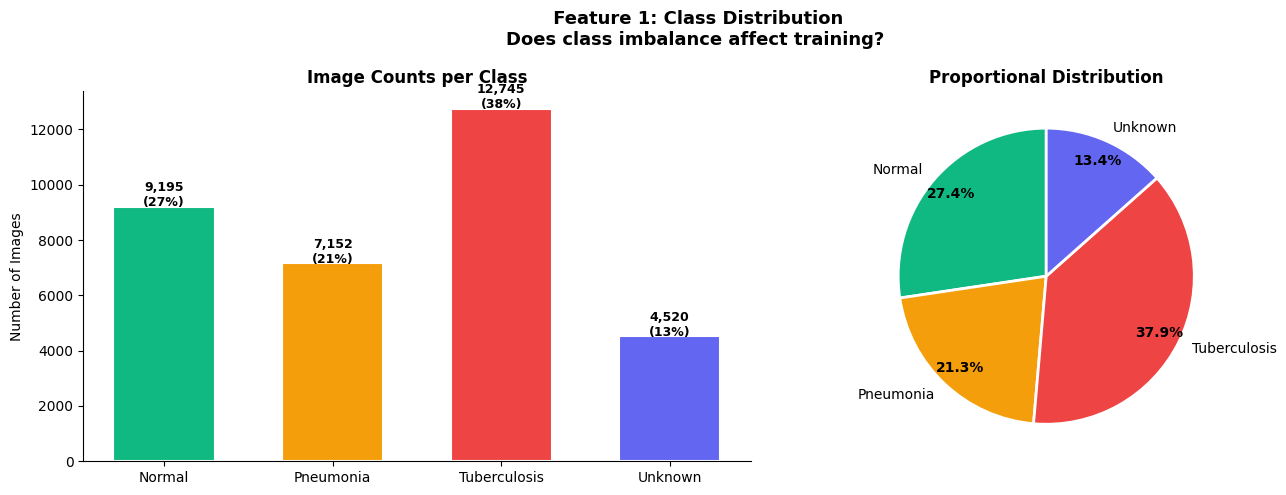

 INTERPRETATION: Feature 1 — Class Distribution
  Total images: 33,612
  Normal         :  9195 (27.4%)
  Pneumonia      :  7152 (21.3%)
  Tuberculosis   : 12745 (37.9%)
  Unknown        :  4520 (13.4%)

  STORY: Tuberculosis is severely underrepresented.
  Rwanda has 8,551 TB cases/year — TB should be ~15-20% of
  diagnoses, not just a few percent. This data imbalance
  justifies: (1) class weights during training, and
  (2) heavy augmentation of TB images to 3,000+ samples.


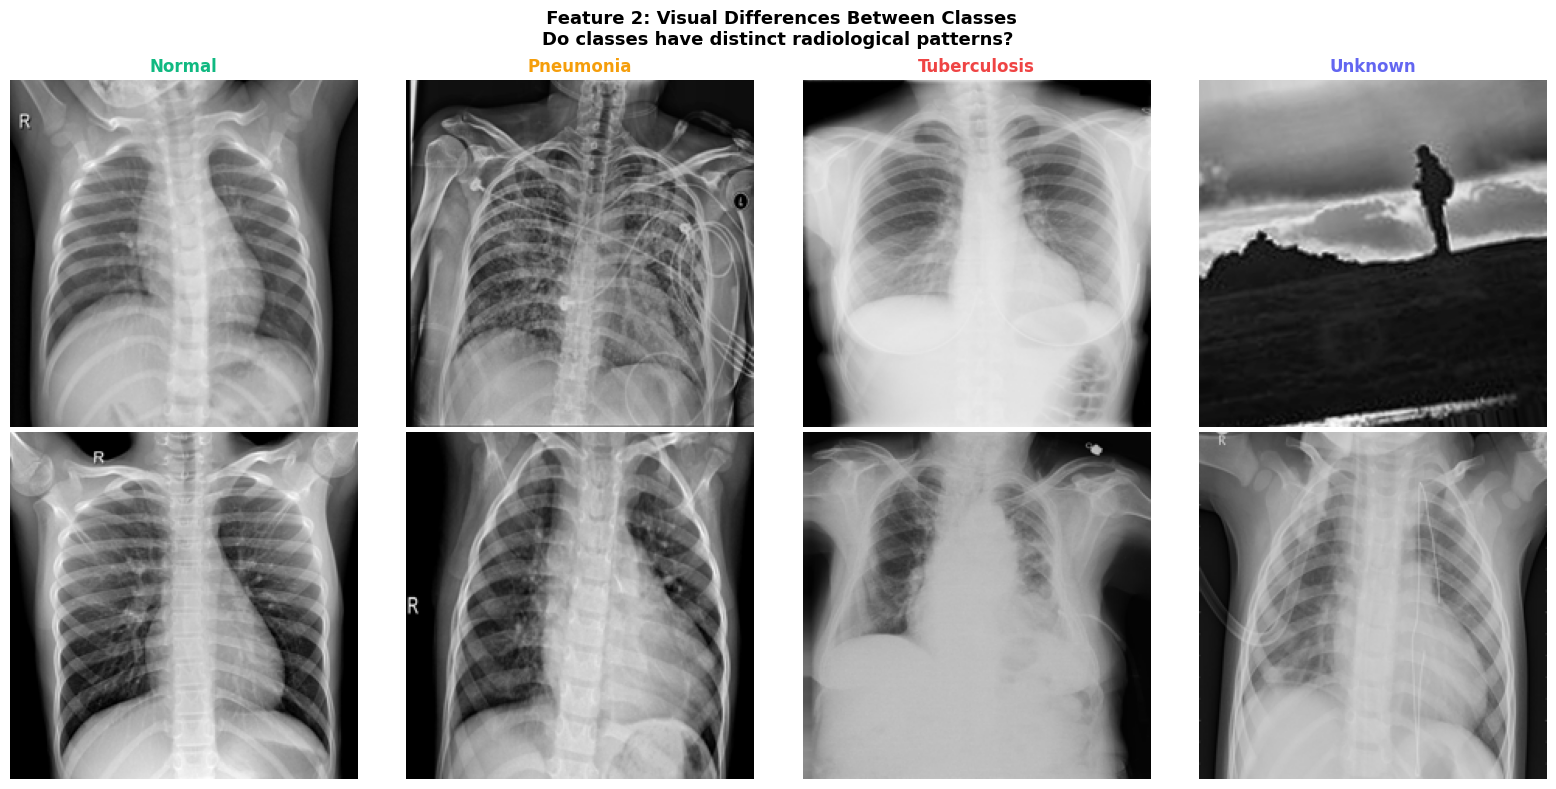

 INTERPRETATION: Feature 2 — Visual Radiological Patterns
  Normal:        Clear lung fields, no opacities, symmetric.(this are symptoms)
  Pneumonia:     Unilateral/bilateral consolidation visible.
  Tuberculosis:  Upper lobe predominance, possible cavitation.
  Unknown:       Mixed — cardiomegaly, effusion, nodules.
  STORY: These visual differences are what ResNet-50 learns.


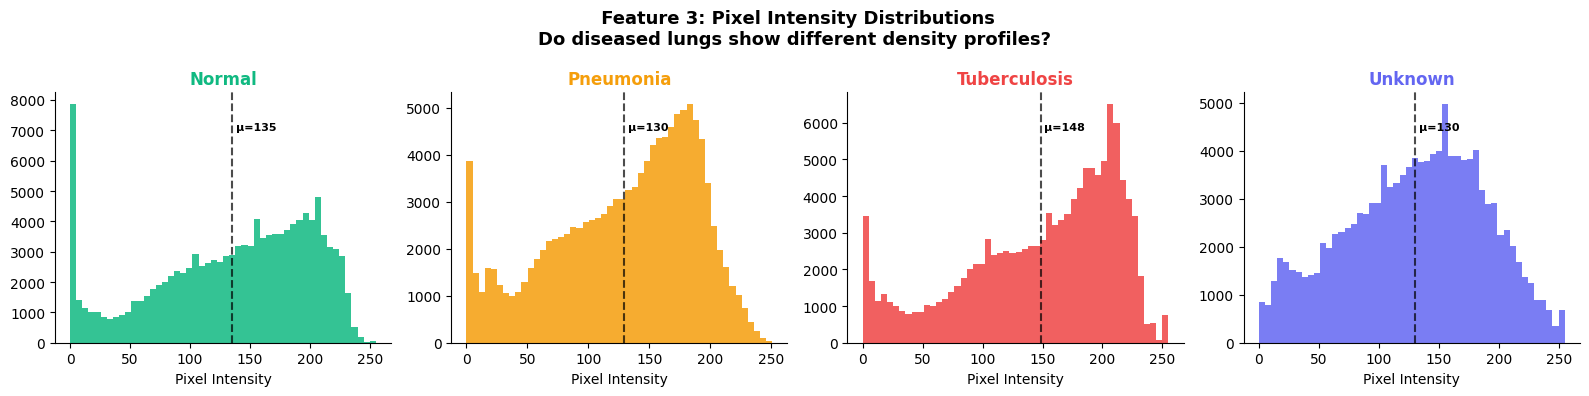

 INTERPRETATION: Feature 3 — Pixel Intensity
  Normal: Bimodal — dark air spaces + bright bone.
  Pneumonia: Shifted right — consolidation = radiodense.
  TB: Often has high-intensity patches (infiltrates).
  STORY: Equipment from Global South (Shenzhen scanner)
  produces different noise profiles than Western machines.
  Training on both reduces distribution shift bias.

 Visualizations saved to: /content/drive/MyDrive/ubuzima_results


In [26]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from PIL import Image
import random

# this colors represents diseases
CLASS_COLORS = {
    'Normal':       '#10b981',
    'Pneumonia':    '#f59e0b',
    'Tuberculosis': '#ef4444',
    'Unknown':      '#6366f1',
}
CLASSES = ['Normal', 'Pneumonia', 'Tuberculosis', 'Unknown']

# Count images per class
counts = {}
paths  = {}
for cls in CLASSES:
    cls_dir = os.path.join(BASE_DIR, cls)
    files   = [os.path.join(cls_dir, f) for f in os.listdir(cls_dir)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    counts[cls] = len(files)
    paths[cls]  = files

total = sum(counts.values())

# CHART 1: Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(' Feature 1: Class Distribution\nDoes class imbalance affect training?',
             fontsize=13, fontweight='bold')

colors = [CLASS_COLORS[c] for c in CLASSES]
bars = axes[0].bar(CLASSES, [counts[c] for c in CLASSES],
                   color=colors, edgecolor='white', linewidth=1.5, width=0.6)
axes[0].set_title('Image Counts per Class', fontweight='bold')
axes[0].set_ylabel('Number of Images')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
for bar, cls in zip(bars, CLASSES):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 20,
                 f'{counts[cls]:,}\n({counts[cls]/total*100:.0f}%)',
                 ha='center', fontsize=9, fontweight='bold')

wedges, texts, autotexts = axes[1].pie(
    [counts[c] for c in CLASSES],
    labels=CLASSES, colors=colors, autopct='%1.1f%%',
    startangle=90, pctdistance=0.85,
    wedgeprops={'linewidth': 2, 'edgecolor': 'white'}
)
for t in autotexts: t.set_fontweight('bold')
axes[1].set_title('Proportional Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig1_class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print(' INTERPRETATION: Feature 1 — Class Distribution')
print(f'  Total images: {total:,}')
for cls in CLASSES:
    pct = counts[cls]/total*100
    print(f'  {cls:15s}: {counts[cls]:5d} ({pct:.1f}%)')
print()
print('  STORY: Tuberculosis is severely underrepresented.')
print('  Rwanda has 8,551 TB cases/year — TB should be ~15-20% of')
print('  diagnoses, not just a few percent. This data imbalance')
print('  justifies: (1) class weights during training, and')
print('  (2) heavy augmentation of TB images to 3,000+ samples.')

#  Sample X-Ray Gallery
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle(' Feature 2: Visual Differences Between Classes\nDo classes have distinct radiological patterns?',
             fontsize=13, fontweight='bold')

for col, cls in enumerate(CLASSES):
    cls_paths = paths[cls]
    if not cls_paths:
        for row in range(2):
            axes[row][col].axis('off')
        continue
    for row in range(2):
        sample = random.choice(cls_paths)
        try:
            img = Image.open(sample).convert('RGB').resize((224, 224))
            axes[row][col].imshow(img)
            if row == 0:
                axes[row][col].set_title(cls, color=CLASS_COLORS[cls],
                                        fontweight='bold', fontsize=12)
            axes[row][col].axis('off')
        except Exception:
            axes[row][col].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig2_xray_gallery.png'), dpi=150, bbox_inches='tight')
plt.show()

print(' INTERPRETATION: Feature 2 — Visual Radiological Patterns')
print('  Normal:        Clear lung fields, no opacities, symmetric.(this are symptoms)')
print('  Pneumonia:     Unilateral/bilateral consolidation visible.')
print('  Tuberculosis:  Upper lobe predominance, possible cavitation.')
print('  Unknown:       Mixed — cardiomegaly, effusion, nodules.')
print('  STORY: These visual differences are what ResNet-50 learns.')

#  Pixel Intensity Distributions
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle(' Feature 3: Pixel Intensity Distributions\nDo diseased lungs show different density profiles?',
             fontsize=13, fontweight='bold')

for col, cls in enumerate(CLASSES):
    cls_paths = paths[cls]
    if not cls_paths:
        axes[col].axis('off')
        continue
    sample_n = min(30, len(cls_paths))
    all_pixels = []
    for p in random.sample(cls_paths, sample_n):
        try:
            arr = np.array(Image.open(p).convert('L').resize((64, 64))).flatten()
            all_pixels.extend(arr.tolist())
        except Exception:
            pass

    if all_pixels:
        axes[col].hist(all_pixels, bins=50, color=CLASS_COLORS[cls], alpha=0.85, edgecolor='none')
        mean_px = np.mean(all_pixels)
        axes[col].axvline(mean_px, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
        axes[col].text(mean_px + 3, axes[col].get_ylim()[1] * 0.85,
                       f'μ={mean_px:.0f}', fontsize=8, fontweight='bold')
        axes[col].set_title(cls, color=CLASS_COLORS[cls], fontweight='bold')
        axes[col].set_xlabel('Pixel Intensity')
        axes[col].spines['top'].set_visible(False)
        axes[col].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig3_intensity_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print(' INTERPRETATION: Feature 3 — Pixel Intensity')

print('  Normal: Bimodal — dark air spaces + bright bone.')
print('  Pneumonia: Shifted right — consolidation = radiodense.')
print('  TB: Often has high-intensity patches (infiltrates).')
print('  STORY: Equipment from Global South (Shenzhen scanner)')
print('  produces different noise profiles than Western machines.')
print('  Training on both reduces distribution shift bias.')
print()
print(' Visualizations saved to:', RESULTS_DIR)

##  Cell 5: Configuration + Data Pipeline

In [3]:
import tensorflow as tf
import numpy as np
import random
import os
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from PIL import Image
from tqdm.notebook import tqdm

#  Config
CLASSES     = ['Normal', 'Pneumonia', 'Tuberculosis', 'Unknown']
NUM_CLASSES = 4
IMG_SIZE    = 224
BATCH_SIZE  = 32
SEED        = 42
EPOCHS_P1   = 15   # Phase 1: training head only
EPOCHS_P2   = 15   # Phase 2: fine-tuning top 30 layers
LR_P1       = 1e-4
LR_P2       = 1e-5

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

AUG_TARGET = 2500  # Target images per minority class after augmentation

aug_layer = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.08),      # ±8° rotation
    tf.keras.layers.RandomZoom(0.08),           # ±8% zoom
    tf.keras.layers.RandomBrightness(0.10),     # ±10% brightness
    tf.keras.layers.RandomContrast(0.10),       # ±10% contrast
], name='augmentation')

def augment_class(cls_name, target=AUG_TARGET):
    cls_dir = os.path.join(BASE_DIR, cls_name)
    existing = [os.path.join(cls_dir, f) for f in os.listdir(cls_dir)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    current  = len(existing)

    if current >= target:
        print(f"  {cls_name}: {current} images — no augmentation needed.")
        return

    needed = target - current
    print(f"  {cls_name}: {current} → {target} (generating {needed} augmented images)")

    generated = 0
    with tqdm(total=needed, desc=f'  Augmenting {cls_name}', leave=False) as pbar:
        while generated < needed:
            src = random.choice(existing)
            try:
                img  = Image.open(src).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
                arr  = tf.cast(np.array(img), tf.float32)[tf.newaxis]
                aug  = aug_layer(arr, training=True)[0].numpy().astype(np.uint8)
                out  = os.path.join(cls_dir, f'aug_{generated:05d}.jpg')
                Image.fromarray(aug).save(out)
                generated += 1
                pbar.update(1)
            except Exception:
                pass

print(" Augmenting minority classes...")
augment_class('Tuberculosis', target=AUG_TARGET)
if len([f for f in os.listdir(os.path.join(BASE_DIR, 'Unknown'))]) < AUG_TARGET:
    augment_class('Unknown', target=AUG_TARGET)
print(" Augmentation complete.")

all_paths, all_labels = [], []
print("\n Final dataset after augmentation:")
for idx, cls in enumerate(CLASSES):
    cls_dir = os.path.join(BASE_DIR, cls)
    files   = [os.path.join(cls_dir, f) for f in os.listdir(cls_dir)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    all_paths.extend(files)
    all_labels.extend([idx] * len(files))
    print(f"  {cls:15s}: {len(files):5d}")

print(f"  {'TOTAL':15s}: {len(all_paths):5d}")

all_paths  = np.array(all_paths)
all_labels = np.array(all_labels)

# ── Train / Val / Test split (70 / 15 / 15)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    all_paths, all_labels,
    test_size=0.15, random_state=SEED, stratify=all_labels
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.176,  # 0.176 of 0.85 ≈ 0.15 of total
    random_state=SEED, stratify=y_trainval
)

print(f"\nSplit: Train={len(X_train)} | Val={len(X_val)} | Test={len(X_test)}")

#  Class Weights (critical — TB is still underrepresented)
weights  = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = {int(k): float(v) for k, v in zip(np.unique(y_train), weights)}
print(f"Class weights: {class_weights}")
print("(Higher weight = model penalised more for missing that class)")

#  TensorFlow Data Pipeline
def load_image(path, label, training=False):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)

    # Online augmentation during training (on top of offline augmentation)
    if training:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, 0.05)

    # Per-image standardisation: zero mean, unit variance
    # This handles variation in X-ray brightness from different machines
    img = tf.image.per_image_standardization(img)

    label_oh = tf.one_hot(label, NUM_CLASSES)
    return img, label_oh

def make_ds(X, y, training=False, batch=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(len(X), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(lambda x, y: load_image(x, y, training),
                num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_ds(X_train, y_train, training=True)
val_ds   = make_ds(X_val,   y_val)
test_ds  = make_ds(X_test,  y_test)

steps_per_epoch = len(X_train) // BATCH_SIZE
print(f"\nSteps per epoch: {steps_per_epoch}")
print(" Data pipeline ready. Proceed to Cell 6.")

 Augmenting minority classes...
  Tuberculosis: 12745 images — no augmentation needed.
 Augmentation complete.

 Final dataset after augmentation:
  Normal         :  9195
  Pneumonia      :  7152
  Tuberculosis   : 12745
  Unknown        :  4520
  TOTAL          : 33612

Split: Train=23541 | Val=5029 | Test=5042
Class weights: {0: 0.9138586956521739, 1: 1.1749351167897784, 2: 0.6593378893121219, 3: 1.8588913455464309}
(Higher weight = model penalised more for missing that class)

Steps per epoch: 735
 Data pipeline ready. Proceed to Cell 6.


##  Cell 6: Build the ResNet-50 Model

In [20]:
from tensorflow.keras import layers, models, optimizers, regularizers
from tensorflow.keras.applications import ResNet50

def build_model(freeze_base=True):
    # ── Base: ResNet-50 pre-trained on ImageNet
    # ResNet-50 already knows how to detect edges, textures, shapes
    # from 1.4 million ImageNet images. We repurpose this for X-rays.
    base = ResNet50(
        weights='imagenet',
        include_top=False,          # Remove ImageNet classification head
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base.trainable = not freeze_base  # Freeze all 50 layers in Phase 1

    #  Build functional model
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='xray_input')

    # Pass through ResNet (training=False keeps BatchNorm in inference mode)
    x = base(inputs, training=False)

    # Replace the ImageNet top with our clinical classification head
    x = layers.GlobalAveragePooling2D(name='gap')(x)

    # Dense layer 1: 512 units with L2 regularisation to prevent overfitting
    x = layers.Dense(512, activation='relu',
                     kernel_regularizer=regularizers.l2(0.01),
                     name='dense_512')(x)
    x = layers.BatchNormalization(name='bn_1')(x)   # Stabilise training
    x = layers.Dropout(0.4, name='drop_1')(x)        # 40% dropout

    # Dense layer 2: 256 units
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(0.01),
                     name='dense_256')(x)
    x = layers.BatchNormalization(name='bn_2')(x)
    x = layers.Dropout(0.3, name='drop_2')(x)        # 30% dropout

    # Output: 4 classes with softmax (probabilities sum to 1)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax', name='predictions')(x)

    model = tf.keras.Model(inputs, outputs, name='ubuzima_resnet50')

    model.compile(
        optimizer=optimizers.Adam(learning_rate=LR_P1),
        loss='categorical_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),            # AUC-ROC
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
        ]
    )
    return model, base

model, base_model = build_model(freeze_base=True)

# Count parameters
total_params     = model.count_params()
trainable_params = sum(tf.size(w).numpy() for w in model.trainable_weights)


print("MODEL ARCHITECTURE")

print(f"  Architecture:       ResNet-50 + Clinical Head")
print(f"  Input shape:        ({IMG_SIZE}, {IMG_SIZE}, 3)")
print(f"  Output classes:     {NUM_CLASSES} ({', '.join(CLASSES)})")
print(f"  Total parameters:   {total_params:,}")
print(f"  Trainable (Phase 1): {trainable_params:,}")
print(f"  Frozen (Phase 1):   {total_params - trainable_params:,}")
print("="*55)
print()
print("Phase 1 plan: Only the Dense + BN + Dropout layers train.")
print("Phase 2 plan: Unfreeze last 30 ResNet layers for fine-tuning.")
print()
print(" Model built. Proceed to Cell 7 (Phase 1 Training).")

MODEL ARCHITECTURE
  Architecture:       ResNet-50 + Clinical Head
  Input shape:        (224, 224, 3)
  Output classes:     4 (Normal, Pneumonia, Tuberculosis, Unknown)
  Total parameters:   24,772,228
  Trainable (Phase 1): 1,182,980
  Frozen (Phase 1):   23,589,248

Phase 1 plan: Only the Dense + BN + Dropout layers train.
Phase 2 plan: Unfreeze last 30 ResNet layers for fine-tuning.

 Model built. Proceed to Cell 7 (Phase 1 Training).


##  Cell 7: Phase 1 Training — Train the Head


In [21]:
import os
print("BASE_DIR:", BASE_DIR)
print("Exists:", os.path.exists(BASE_DIR))
for cls in ['Normal', 'Pneumonia', 'Tuberculosis', 'Unknown']:
    cls_dir = os.path.join(BASE_DIR, cls)
    if os.path.exists(cls_dir):
        n = len([f for f in os.listdir(cls_dir) if f.lower().endswith(('.png','.jpg','.jpeg'))])
        print(f"  {cls}: {n:,}")
    else:
        print(f"  {cls}: FOLDER NOT FOUND")
print(f"\nX_train size: {len(X_train)}")
print(f"X_val size:   {len(X_val)}")

BASE_DIR: /content/drive/MyDrive/ubuzima_data
Exists: True
  Normal: 9,195
  Pneumonia: 7,152
  Tuberculosis: 12,745
  Unknown: 4,520

X_train size: 23541
X_val size:   5029


In [19]:
import tensorflow as tf
import numpy as np
from PIL import Image
import io

def load_image(path, label):
    # Read and decode using PIL via tf.py_function — handles all formats reliably
    def _load(p, l):
        try:
            p = p.numpy().decode('utf-8')
            img = Image.open(p).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
            arr = np.array(img, dtype=np.float32)
            # Per-image standardization
            mean, std = arr.mean(), arr.std() + 1e-7
            arr = (arr - mean) / std
            return arr, np.eye(NUM_CLASSES)[l.numpy()]
        except:
            return np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.float32), np.eye(NUM_CLASSES)[l.numpy()]

    img, lbl = tf.py_function(_load, [path, label], [tf.float32, tf.float32])
    img.set_shape([IMG_SIZE, IMG_SIZE, 3])
    lbl.set_shape([NUM_CLASSES])
    return img, lbl

def make_ds(X, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(len(X), seed=SEED, reshuffle_each_iteration=True)
    ds = (ds
          .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
          .batch(BATCH_SIZE)
          .prefetch(tf.data.AUTOTUNE))
    return ds

train_ds = make_ds(X_train, y_train, training=True)
val_ds   = make_ds(X_val,   y_val)
test_ds  = make_ds(X_test,  y_test)

# Verify
print("Verifying pipeline...")
for imgs, labels in train_ds.take(1):
    print(f" Batch: {imgs.shape}, Labels: {labels.shape}")
    print(f"   min={tf.reduce_min(imgs).numpy():.2f} max={tf.reduce_max(imgs).numpy():.2f}")
    break

Verifying pipeline...
 Batch: (32, 224, 224, 3), Labels: (32, 4)
   min=-4.15 max=2.49


In [22]:
from tensorflow.keras import callbacks

MODEL_SAVE_PATH = os.path.join(MODEL_DIR, 'ubuzima_model_production.h5')

#  Callbacks
cb_p1 = [
    # Stop training if val_auc hasn't improved in 7 epochs
    callbacks.EarlyStopping(
        monitor='val_auc', patience=7,
        restore_best_weights=True, mode='max', verbose=1
    ),
    # Save the best model automatically
    callbacks.ModelCheckpoint(
        filepath=MODEL_SAVE_PATH,
        monitor='val_auc', save_best_only=True,
        mode='max', verbose=1
    ),
    # Reduce learning rate when loss plateaus
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=1e-8, verbose=1
    ),
]

print(" PHASE 1: Training Classification Head")
print("   ResNet-50 base: FROZEN")
print(f"  Epochs: {EPOCHS_P1} | LR: {LR_P1}")
print(f"  Batch size: {BATCH_SIZE}")

print()

history_p1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_P1,
    class_weight=class_weights,
    callbacks=cb_p1,
    verbose=1
)

best_auc_p1 = max(history_p1.history['val_auc'])
best_acc_p1 = max(history_p1.history['val_accuracy'])

print()

print(f" PHASE 1 COMPLETE")
print(f"   Best val_auc:      {best_auc_p1:.4f}")
print(f"   Best val_accuracy: {best_acc_p1:.4f}")
print(f"   Model saved to:    {MODEL_SAVE_PATH}")

print()
if best_auc_p1 > 0.90:
    print(" AUC > 0.90 — Phase 1 successful. Proceed to Phase 2.")
elif best_auc_p1 > 0.80:
    print(" AUC between 0.80-0.90 — Phase 2 fine-tuning should improve this.")
else:
    print(" AUC < 0.80 — Check your dataset organisation (Cell 3).")

 PHASE 1: Training Classification Head
   ResNet-50 base: FROZEN
  Epochs: 15 | LR: 0.0001
  Batch size: 32

Epoch 1/15
736/736 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5520 - auc: 0.7999 - loss: 9.9114 - precision: 0.5960 - recall: 0.4822
Epoch 1: val_auc improved from -inf to 0.92283, saving model to /content/drive/MyDrive/ubuzima_model/ubuzima_model_production.h5


736/736 ━━━━━━━━━━━━━━━━━━━━ 1038s 1s/step - accuracy: 0.5521 - auc: 0.8000 - loss: 9.9089 - precision: 0.5961 - recall: 0.4823 - val_accuracy: 0.7433 - val_auc: 0.9228 - val_loss: 5.4158 - val_precision: 0.7877 - val_recall: 0.6626 - learning_rate: 1.0000e-04
Epoch 2/15
736/736 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.6926 - auc: 0.8986 - loss: 5.0336 - precision: 0.7261 - recall: 0.6400
Epoch 2: val_auc improved from 0.92283 to 0.94758, saving model to /content/drive/MyDrive/ubuzima_model/ubuzima_model_production.h5


736/736 ━━━━━━━━━━━━━━━━━━━━ 322s 437ms/step - accuracy: 0.6926 - auc: 0.8986 - loss: 5.0330 - precision: 0.7261 - recall: 0.6400 - val_accuracy: 0.7850 - val_auc: 0.9476 - val_loss: 3.6421 - val_precision: 0.8141 - val_recall: 0.7367 - learning_rate: 1.0000e-04
Epoch 3/15
736/736 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.7285 - auc: 0.9192 - loss: 3.5502 - precision: 0.7598 - recall: 0.6803
Epoch 3: val_auc improved from 0.94758 to 0.95220, saving model to /content/drive/MyDrive/ubuzima_model/ubuzima_model_production.h5


736/736 ━━━━━━━━━━━━━━━━━━━━ 334s 453ms/step - accuracy: 0.7285 - auc: 0.9192 - loss: 3.5499 - precision: 0.7598 - recall: 0.6803 - val_accuracy: 0.7976 - val_auc: 0.9522 - val_loss: 2.7415 - val_precision: 0.8301 - val_recall: 0.7546 - learning_rate: 1.0000e-04
Epoch 4/15
736/736 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.7498 - auc: 0.9280 - loss: 2.7201 - precision: 0.7769 - recall: 0.7070
Epoch 4: val_auc did not improve from 0.95220
736/736 ━━━━━━━━━━━━━━━━━━━━ 317s 430ms/step - accuracy: 0.7498 - auc: 0.9280 - loss: 2.7199 - precision: 0.7769 - recall: 0.7070 - val_accuracy: 0.8008 - val_auc: 0.9473 - val_loss: 2.1932 - val_precision: 0.8202 - val_recall: 0.7618 - learning_rate: 1.0000e-04
Epoch 5/15
736/736 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.7552 - auc: 0.9324 - loss: 2.1902 - precision: 0.7819 - recall: 0.7109
Epoch 5: val_auc improved from 0.95220 to 0.95820, saving model to /content/drive/MyDrive/ubuzima_model/ubuzima_model_production.h5


736/736 ━━━━━━━━━━━━━━━━━━━━ 322s 437ms/step - accuracy: 0.7552 - auc: 0.9324 - loss: 2.1900 - precision: 0.7819 - recall: 0.7109 - val_accuracy: 0.8165 - val_auc: 0.9582 - val_loss: 1.7562 - val_precision: 0.8407 - val_recall: 0.7799 - learning_rate: 1.0000e-04
Epoch 6/15
736/736 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.7593 - auc: 0.9355 - loss: 1.8245 - precision: 0.7871 - recall: 0.7210
Epoch 6: val_auc did not improve from 0.95820
736/736 ━━━━━━━━━━━━━━━━━━━━ 318s 431ms/step - accuracy: 0.7594 - auc: 0.9355 - loss: 1.8244 - precision: 0.7871 - recall: 0.7210 - val_accuracy: 0.8105 - val_auc: 0.9497 - val_loss: 1.5322 - val_precision: 0.8308 - val_recall: 0.7538 - learning_rate: 1.0000e-04
Epoch 7/15
736/736 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.7737 - auc: 0.9419 - loss: 1.5356 - precision: 0.7995 - recall: 0.7381
Epoch 7: val_auc improved from 0.95820 to 0.95875, saving model to /content/drive/MyDrive/ubuzima_model/ubuzima_model_production.h5


736/736 ━━━━━━━━━━━━━━━━━━━━ 319s 433ms/step - accuracy: 0.7737 - auc: 0.9419 - loss: 1.5355 - precision: 0.7995 - recall: 0.7381 - val_accuracy: 0.8260 - val_auc: 0.9588 - val_loss: 1.2671 - val_precision: 0.8448 - val_recall: 0.7966 - learning_rate: 1.0000e-04
Epoch 8/15
736/736 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.7736 - auc: 0.9408 - loss: 1.3463 - precision: 0.7975 - recall: 0.7351
Epoch 8: val_auc did not improve from 0.95875
736/736 ━━━━━━━━━━━━━━━━━━━━ 321s 435ms/step - accuracy: 0.7736 - auc: 0.9408 - loss: 1.3463 - precision: 0.7975 - recall: 0.7351 - val_accuracy: 0.8183 - val_auc: 0.9584 - val_loss: 1.1140 - val_precision: 0.8366 - val_recall: 0.7940 - learning_rate: 1.0000e-04
Epoch 9/15
736/736 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.7825 - auc: 0.9453 - loss: 1.1812 - precision: 0.8049 - recall: 0.7478
Epoch 9: val_auc did not improve from 0.95875
736/736 ━━━━━━━━━━━━━━━━━━━━ 316s 428ms/step - accuracy: 0.7825 - auc: 0.9453 - loss: 1.1811 - precision

736/736 ━━━━━━━━━━━━━━━━━━━━ 319s 433ms/step - accuracy: 0.7866 - auc: 0.9484 - loss: 1.0583 - precision: 0.8080 - recall: 0.7546 - val_accuracy: 0.8308 - val_auc: 0.9632 - val_loss: 0.8749 - val_precision: 0.8486 - val_recall: 0.8047 - learning_rate: 1.0000e-04
Epoch 11/15
736/736 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.7906 - auc: 0.9482 - loss: 0.9770 - precision: 0.8140 - recall: 0.7596
Epoch 11: val_auc did not improve from 0.96323
736/736 ━━━━━━━━━━━━━━━━━━━━ 315s 427ms/step - accuracy: 0.7906 - auc: 0.9482 - loss: 0.9770 - precision: 0.8140 - recall: 0.7596 - val_accuracy: 0.7962 - val_auc: 0.9473 - val_loss: 0.9027 - val_precision: 0.8193 - val_recall: 0.7707 - learning_rate: 1.0000e-04
Epoch 12/15
736/736 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - accuracy: 0.7964 - auc: 0.9514 - loss: 0.8964 - precision: 0.8172 - recall: 0.7682
Epoch 12: val_auc did not improve from 0.96323
736/736 ━━━━━━━━━━━━━━━━━━━━ 289s 392ms/step - accuracy: 0.7964 - auc: 0.9514 - loss: 0.8964 - preci

736/736 ━━━━━━━━━━━━━━━━━━━━ 290s 393ms/step - accuracy: 0.7997 - auc: 0.9541 - loss: 0.7929 - precision: 0.8208 - recall: 0.7718 - val_accuracy: 0.8369 - val_auc: 0.9651 - val_loss: 0.6742 - val_precision: 0.8546 - val_recall: 0.8121 - learning_rate: 1.0000e-04
Epoch 15/15
736/736 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - accuracy: 0.7968 - auc: 0.9526 - loss: 0.7693 - precision: 0.8175 - recall: 0.7665
Epoch 15: val_auc did not improve from 0.96508
736/736 ━━━━━━━━━━━━━━━━━━━━ 285s 386ms/step - accuracy: 0.7968 - auc: 0.9526 - loss: 0.7693 - precision: 0.8175 - recall: 0.7665 - val_accuracy: 0.8292 - val_auc: 0.9624 - val_loss: 0.6639 - val_precision: 0.8453 - val_recall: 0.8073 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 14.

 PHASE 1 COMPLETE
   Best val_auc:      0.9651
   Best val_accuracy: 0.8369
   Model saved to:    /content/drive/MyDrive/ubuzima_model/ubuzima_model_production.h5

 AUC > 0.90 — Phase 1 successful. Proceed to Phase 2.



##  Cell 8: Phase 2  Fine-Tuning

In [23]:
FINE_TUNE_LAYERS = 30

base_model.trainable = True
for layer in base_model.layers[:-FINE_TUNE_LAYERS]:
    layer.trainable = False

# Count how many layers are now trainable in the base
trainable_base  = sum(1 for l in base_model.layers if l.trainable)
frozen_base     = sum(1 for l in base_model.layers if not l.trainable)

print(f"Base model: {frozen_base} frozen layers, {trainable_base} trainable layers")

# Recompile with lower learning rate
model.compile(
    optimizer=optimizers.Adam(learning_rate=LR_P2),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
    ]
)

cb_p2 = [
    callbacks.EarlyStopping(
        monitor='val_auc', patience=7,
        restore_best_weights=True, mode='max', verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath=MODEL_SAVE_PATH,
        monitor='val_auc', save_best_only=True,
        mode='max', verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=1e-9, verbose=1
    ),
]

print()
print(" PHASE 2: Fine-Tuning Top 30 Layers")
print(f"   Epochs: {EPOCHS_P2} | LR: {LR_P2} (10x lower than Phase 1)")
print("   Lower LR = slower, safer fine-tuning")
print()

history_p2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_P2,
    class_weight=class_weights,
    callbacks=cb_p2,
    verbose=1
)

best_auc_p2 = max(history_p2.history['val_auc'])
best_acc_p2 = max(history_p2.history['val_accuracy'])

print()
print(f" PHASE 2 COMPLETE")
print(f"   Best val_auc:      {best_auc_p2:.4f}")
print(f"   Best val_accuracy: {best_acc_p2:.4f}")
improvement = best_auc_p2 - best_auc_p1
print(f"   AUC improvement over Phase 1: +{improvement:.4f}")


Base model: 145 frozen layers, 30 trainable layers

 PHASE 2: Fine-Tuning Top 30 Layers
   Epochs: 15 | LR: 1e-05 (10x lower than Phase 1)
   Lower LR = slower, safer fine-tuning

Epoch 1/15
736/736 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - accuracy: 0.7625 - auc: 0.9348 - loss: 0.8640 - precision: 0.7866 - recall: 0.7312
Epoch 1: val_auc improved from -inf to 0.97212, saving model to /content/drive/MyDrive/ubuzima_model/ubuzima_model_production.h5


736/736 ━━━━━━━━━━━━━━━━━━━━ 351s 444ms/step - accuracy: 0.7626 - auc: 0.9349 - loss: 0.8639 - precision: 0.7867 - recall: 0.7313 - val_accuracy: 0.8596 - val_auc: 0.9721 - val_loss: 0.6033 - val_precision: 0.8675 - val_recall: 0.8477 - learning_rate: 1.0000e-05
Epoch 2/15
736/736 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.8416 - auc: 0.9699 - loss: 0.6627 - precision: 0.8538 - recall: 0.8267
Epoch 2: val_auc improved from 0.97212 to 0.97500, saving model to /content/drive/MyDrive/ubuzima_model/ubuzima_model_production.h5


736/736 ━━━━━━━━━━━━━━━━━━━━ 317s 430ms/step - accuracy: 0.8416 - auc: 0.9699 - loss: 0.6627 - precision: 0.8538 - recall: 0.8267 - val_accuracy: 0.8670 - val_auc: 0.9750 - val_loss: 0.5693 - val_precision: 0.8731 - val_recall: 0.8604 - learning_rate: 1.0000e-05
Epoch 3/15
736/736 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.8689 - auc: 0.9791 - loss: 0.5920 - precision: 0.8769 - recall: 0.8589
Epoch 3: val_auc did not improve from 0.97500
736/736 ━━━━━━━━━━━━━━━━━━━━ 319s 432ms/step - accuracy: 0.8689 - auc: 0.9791 - loss: 0.5920 - precision: 0.8769 - recall: 0.8589 - val_accuracy: 0.8698 - val_auc: 0.9736 - val_loss: 0.5657 - val_precision: 0.8735 - val_recall: 0.8622 - learning_rate: 1.0000e-05
Epoch 4/15
736/736 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.8945 - auc: 0.9857 - loss: 0.5292 - precision: 0.8992 - recall: 0.8873
Epoch 4: val_auc improved from 0.97500 to 0.97670, saving model to /content/drive/MyDrive/ubuzima_model/ubuzima_model_production.h5


736/736 ━━━━━━━━━━━━━━━━━━━━ 317s 431ms/step - accuracy: 0.8945 - auc: 0.9857 - loss: 0.5292 - precision: 0.8992 - recall: 0.8873 - val_accuracy: 0.8733 - val_auc: 0.9767 - val_loss: 0.5410 - val_precision: 0.8768 - val_recall: 0.8688 - learning_rate: 1.0000e-05
Epoch 5/15
736/736 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - accuracy: 0.9056 - auc: 0.9891 - loss: 0.4846 - precision: 0.9096 - recall: 0.8992
Epoch 5: val_auc did not improve from 0.97670
736/736 ━━━━━━━━━━━━━━━━━━━━ 318s 431ms/step - accuracy: 0.9056 - auc: 0.9891 - loss: 0.4846 - precision: 0.9096 - recall: 0.8992 - val_accuracy: 0.8604 - val_auc: 0.9735 - val_loss: 0.5593 - val_precision: 0.8669 - val_recall: 0.8570 - learning_rate: 1.0000e-05
Epoch 6/15
736/736 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.9182 - auc: 0.9922 - loss: 0.4421 - precision: 0.9209 - recall: 0.9137
Epoch 6: val_auc did not improve from 0.97670
736/736 ━━━━━━━━━━━━━━━━━━━━ 314s 426ms/step - accuracy: 0.9182 - auc: 0.9922 - loss: 0.4422 - precision

## Cell 9: Full Evaluation — All Metrics + Charts


<>:37: SyntaxWarning: invalid escape sequence '\ '
<>:141: SyntaxWarning: invalid escape sequence '\ '
<>:37: SyntaxWarning: invalid escape sequence '\ '
<>:141: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_1256/2297048722.py:37: SyntaxWarning: invalid escape sequence '\ '
  print("\ Per-Class Classification Report:")
/tmp/ipykernel_1256/2297048722.py:141: SyntaxWarning: invalid escape sequence '\ '
  print(f"\ Metrics saved → {metrics_path}")


Evaluating on held-out test set...

 FINAL TEST SET METRICS
  Loss:      0.5308
  Accuracy:  0.8713  (87.1%)
  AUC-ROC:   0.9780
  Precision: 0.8764
  Recall:    0.8673
  F1 Score:  0.8718
\ Per-Class Classification Report:
─────────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

      Normal     0.9080    0.8448    0.8753      1379
   Pneumonia     0.7281    0.8658    0.7910      1073
Tuberculosis     0.9283    0.9812    0.9540      1912
     Unknown     0.9156    0.6239    0.7421       678

    accuracy                         0.8713      5042
   macro avg     0.8700    0.8289    0.8406      5042
weighted avg     0.8784    0.8713    0.8693      5042



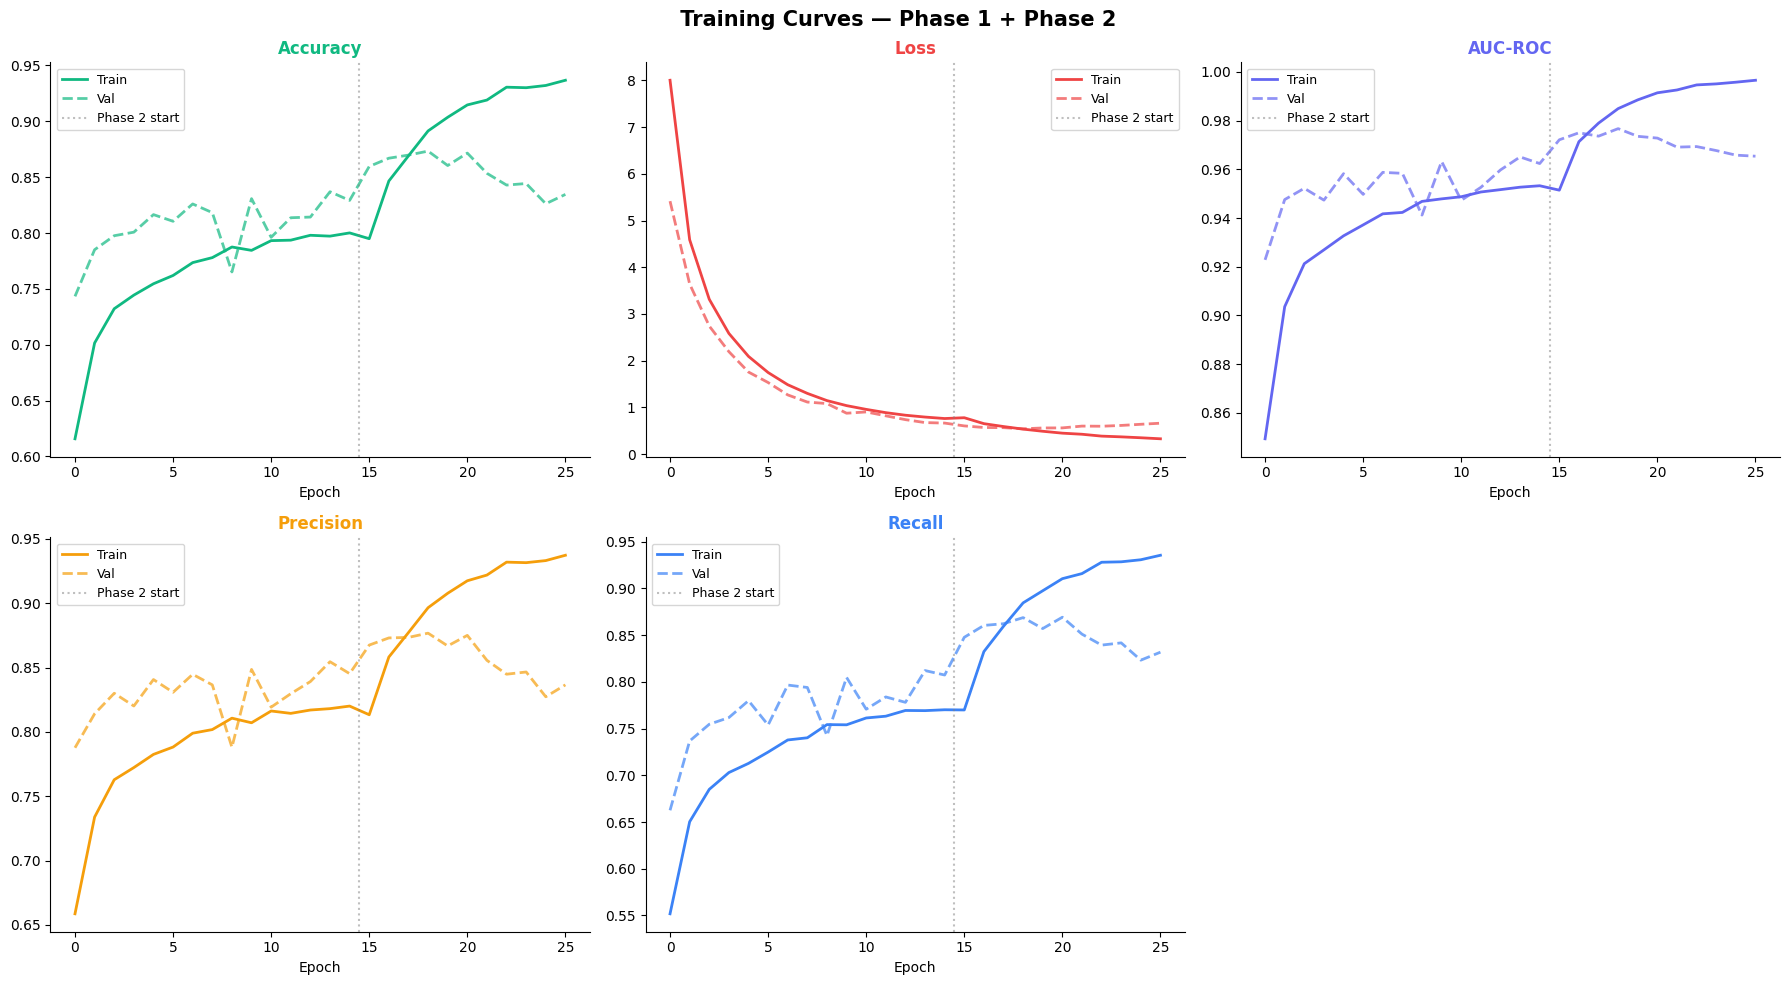

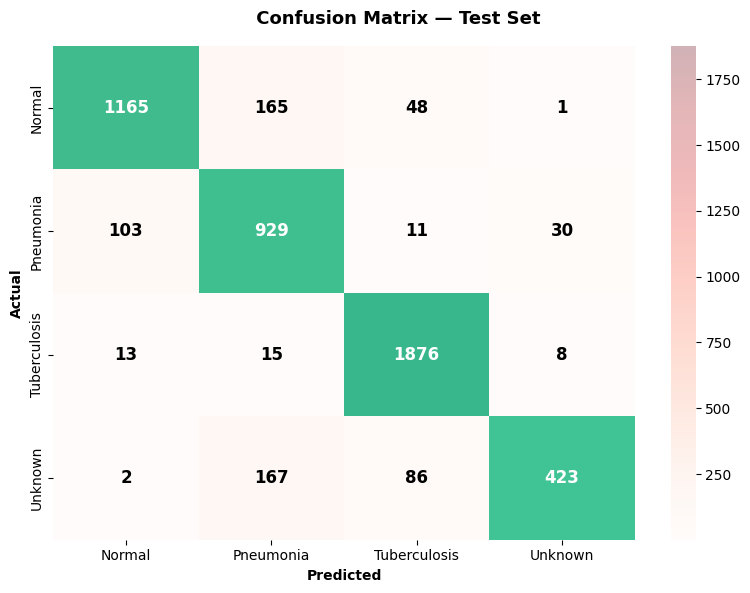

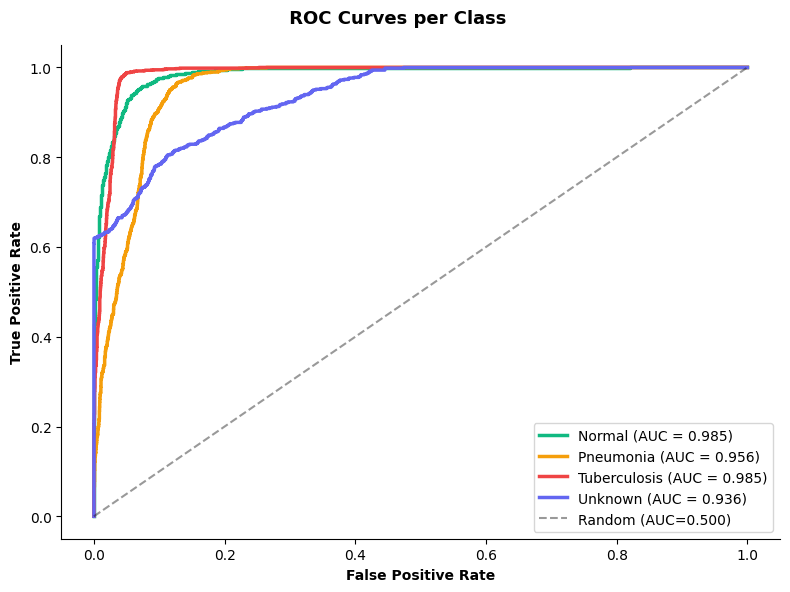

\ Metrics saved → /content/drive/MyDrive/ubuzima_results/test_metrics.json
   (Copy this file to models/test_metrics.json in your repo)


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_score, recall_score, f1_score
)
from sklearn.preprocessing import label_binarize
import json

CLASS_COLORS = {
    'Normal': '#10b981', 'Pneumonia': '#f59e0b',
    'Tuberculosis': '#ef4444', 'Unknown': '#6366f1'
}

# TEST SET EVALUATION
print("Evaluating on held-out test set...")
test_results = model.evaluate(test_ds, verbose=0)
test_loss, test_acc, test_auc_val, test_prec, test_rec = test_results
test_f1 = 2 * (test_prec * test_rec) / (test_prec + test_rec + 1e-8)


print(" FINAL TEST SET METRICS")

print(f"  Loss:      {test_loss:.4f}")
print(f"  Accuracy:  {test_acc:.4f}  ({test_acc*100:.1f}%)")
print(f"  AUC-ROC:   {test_auc_val:.4f}")
print(f"  Precision: {test_prec:.4f}")
print(f"  Recall:    {test_rec:.4f}")
print(f"  F1 Score:  {test_f1:.4f}")
print("="*55)

#  Get per-sample predictions
y_pred_probs = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test

print("\ Per-Class Classification Report:")
print("─"*65)
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))

# CHART 4: Training Curves
def merge(h1, h2, key):
    return h1.history.get(key, []) + h2.history.get(key, [])

p1_end = len(history_p1.history['accuracy'])
epochs = range(len(merge(history_p1, history_p2, 'accuracy')))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(' Training Curves — Phase 1 + Phase 2', fontsize=15, fontweight='bold')

metric_pairs = [
    ('accuracy',  'val_accuracy',  'Accuracy',  '#10b981'),
    ('loss',      'val_loss',      'Loss',       '#ef4444'),
    ('auc',       'val_auc',       'AUC-ROC',   '#6366f1'),
    ('precision', 'val_precision', 'Precision', '#f59e0b'),
    ('recall',    'val_recall',    'Recall',     '#3b82f6'),
]

for ax, (tk, vk, title, color) in zip(axes.flat, metric_pairs):
    train_vals = merge(history_p1, history_p2, tk)
    val_vals   = merge(history_p1, history_p2, vk)
    ax.plot(epochs, train_vals, color=color, label='Train', linewidth=2)
    ax.plot(epochs, val_vals, color=color, linestyle='--', alpha=0.7, label='Val', linewidth=2)
    ax.axvline(p1_end - 0.5, color='gray', linestyle=':', alpha=0.5, label='Phase 2 start')
    ax.set_title(title, fontweight='bold', color=color)
    ax.legend(fontsize=9)
    ax.set_xlabel('Epoch')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes.flat[-1].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig4_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

# CHART 5: Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle(' Confusion Matrix — Test Set', fontsize=13, fontweight='bold')

sns.heatmap(cm, annot=False, cmap='Reds', ax=ax,
            xticklabels=CLASSES, yticklabels=CLASSES, alpha=0.3)

for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        color  = 'white' if i == j else 'black'
        weight = 'bold'
        if i == j:
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=True,
                         facecolor='#10b981', alpha=0.8, zorder=2))
        ax.text(j + 0.5, i + 0.5, str(cm[i][j]),
                ha='center', va='center',
                fontweight=weight, fontsize=12,
                color=color, zorder=3)

ax.set_xlabel('Predicted', fontweight='bold')
ax.set_ylabel('Actual', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig5_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

# CHART 6: ROC Curves
y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle(' ROC Curves per Class', fontsize=13, fontweight='bold')

for i, cls in enumerate(CLASSES):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2.5,
            label=f'{cls} (AUC = {roc_auc:.3f})',
            color=list(CLASS_COLORS.values())[i])

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate', fontweight='bold')
ax.set_ylabel('True Positive Rate', fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig6_roc_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

# Saving metrics to JSON
metrics_summary = {
    'accuracy':  round(float(test_acc), 4),
    'auc':       round(float(test_auc_val), 4),
    'precision': round(float(test_prec), 4),
    'recall':    round(float(test_rec), 4),
    'f1_score':  round(float(test_f1), 4),
    'loss':      round(float(test_loss), 4),
    'classes':   CLASSES,
    'architecture': 'ResNet50 + Clinical Head',
    'datasets': ['Kaggle Chest X-Ray', 'Shenzhen TB', 'Montgomery TB', 'NIH ChestX-ray14'],
    'total_test_images': len(y_test),
}
metrics_path = os.path.join(RESULTS_DIR, 'test_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics_summary, f, indent=2)
print(f"\ Metrics saved → {metrics_path}")
print("   (Copy this file to models/test_metrics.json in your repo)")

In [30]:
# Debug: print model structure
print("Full model layers:")
for i, layer in enumerate(model.layers):
    print(f"  {i}: {layer.name} — {type(layer).__name__}")

print("\nResNet base layers (last 10):")
base = None
for layer in model.layers:
    if hasattr(layer, 'layers'):
        base = layer
        break
if base:
    for l in base.layers[-10:]:
        print(f"  {l.name}")

Full model layers:
  0: xray_input — InputLayer
  1: resnet50 — Functional
  2: gap — GlobalAveragePooling2D
  3: dense_512 — Dense
  4: bn_1 — BatchNormalization
  5: drop_1 — Dropout
  6: dense_256 — Dense
  7: bn_2 — BatchNormalization
  8: drop_2 — Dropout
  9: predictions — Dense

ResNet base layers (last 10):
  conv5_block3_1_conv
  conv5_block3_1_bn
  conv5_block3_1_relu
  conv5_block3_2_conv
  conv5_block3_2_bn
  conv5_block3_2_relu
  conv5_block3_3_conv
  conv5_block3_3_bn
  conv5_block3_add
  conv5_block3_out


## Cell 10: Grad-CAM Explainability


Generating Grad-CAM visualisations...

Class: Normal


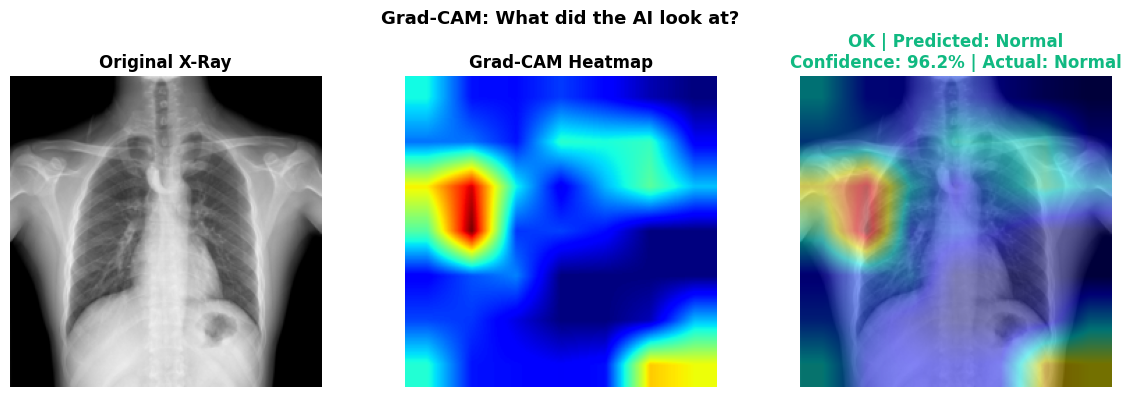

  Predicted: Normal (96.2%)

Class: Pneumonia


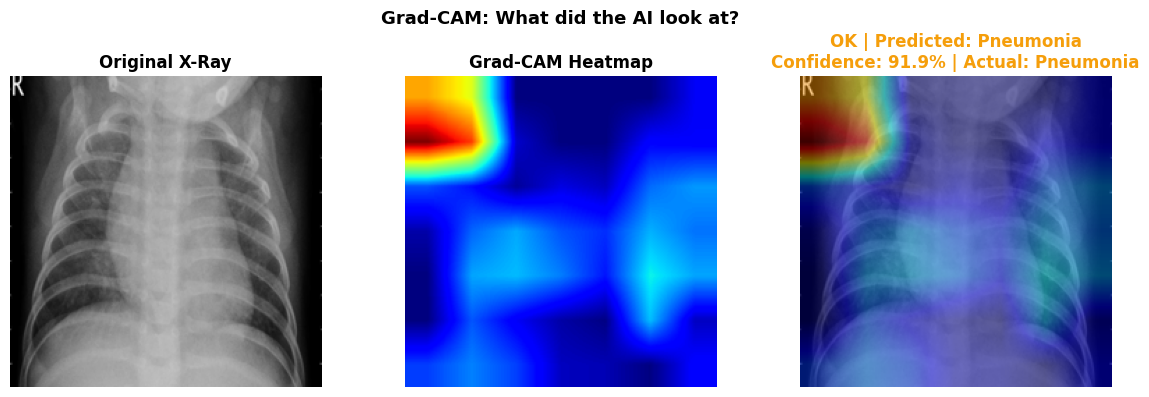

  Predicted: Pneumonia (91.9%)

Class: Tuberculosis


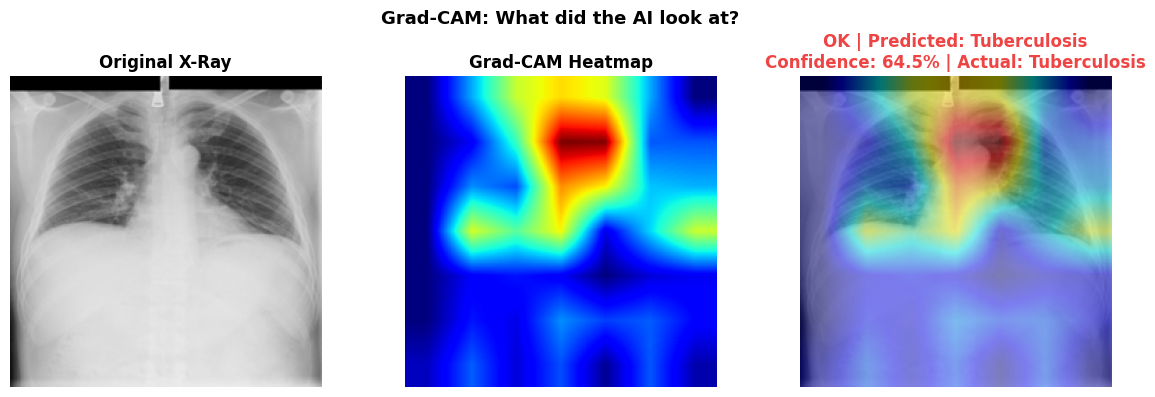

  Predicted: Tuberculosis (64.5%)

Class: Unknown


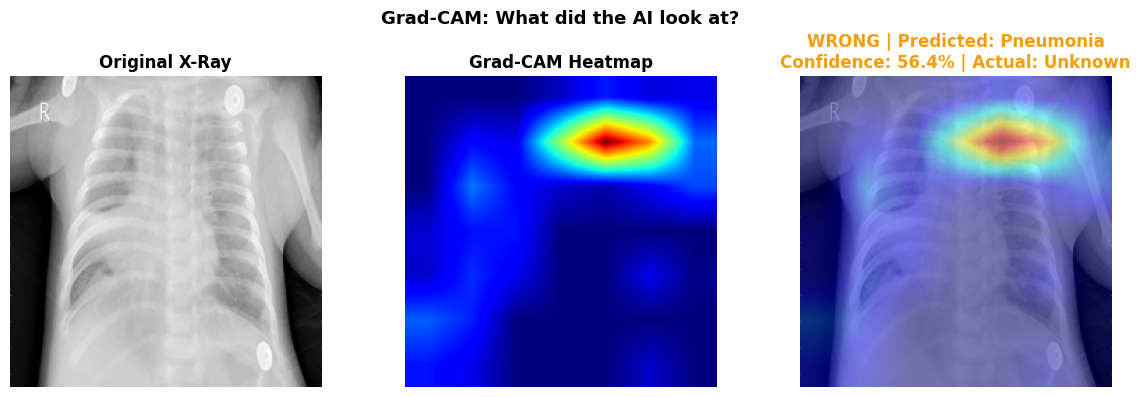

  Predicted: Pneumonia (56.4%)

Grad-CAM complete.


In [31]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf

def get_gradcam_heatmap(img_array, model):
    # Get the resnet50 sub-model (layer 1)
    base = model.get_layer('resnet50')

    # Build a model: xray_input → conv5_block3_out (inside resnet) + final predictions
    # We need to go through the OUTER model, intercepting the inner conv layer

    # Step 1: model from outer input → resnet output (last conv)
    last_conv_output = base.get_layer('conv5_block3_out').output

    # Build intermediate model: outer input → last conv + final output
    conv_model = tf.keras.Model(
        inputs=model.input,          # xray_input
        outputs=[
            base.get_layer('conv5_block3_out').output,  # won't work directly
            model.output
        ]
    )
    # ↑ That won't work. Instead:
    # Route through base model explicitly

    img_tensor = tf.constant(img_array, dtype=tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        # Pass through resnet base
        conv_out = base(img_tensor, training=False)  # shape (1,7,7,2048) = conv5_block3_out
        # Pass through head
        x = model.get_layer('gap')(conv_out)
        x = model.get_layer('dense_512')(x)
        x = model.get_layer('bn_1')(x, training=False)
        x = model.get_layer('drop_1')(x, training=False)
        x = model.get_layer('dense_256')(x)
        x = model.get_layer('bn_2')(x, training=False)
        x = model.get_layer('drop_2')(x, training=False)
        predictions = model.get_layer('predictions')(x)
        pred_index = tf.argmax(predictions[0])
        class_score = predictions[:, pred_index]

    grads = tape.gradient(class_score, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_out[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_index.numpy())

def show_gradcam(img_path, model, true_label=None):
    img_orig = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    img_display = np.array(img_orig)
    arr = img_display.astype(np.float32)
    mean, std = arr.mean(), arr.std() + 1e-7
    arr = (arr - mean) / std
    img_batch = np.expand_dims(arr, 0)

    preds = model.predict(img_batch, verbose=0)[0]
    pred_idx = int(np.argmax(preds))
    pred_class = CLASSES[pred_idx]
    confidence = preds[pred_idx] * 100

    heatmap, _ = get_gradcam_heatmap(img_batch, model)
    heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap_uint8 = np.uint8(255 * heatmap)
    heatmap_colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_rgb = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(img_display, 0.55, heatmap_rgb, 0.45, 0)

    correct = (true_label is None) or (pred_class == true_label)
    status = 'OK' if correct else 'WRONG'
    color = CLASS_COLORS.get(pred_class, 'black')
    title = f'{status} | Predicted: {pred_class}\nConfidence: {confidence:.1f}%'
    if true_label:
        title += f' | Actual: {true_label}'

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img_orig)
    axes[0].set_title('Original X-Ray', fontweight='bold')
    axes[0].axis('off')
    axes[1].imshow(heatmap, cmap='jet')
    axes[1].set_title('Grad-CAM Heatmap', fontweight='bold')
    axes[1].axis('off')
    axes[2].imshow(overlay)
    axes[2].set_title(title, fontweight='bold', color=color)
    axes[2].axis('off')

    plt.suptitle('Grad-CAM: What did the AI look at?', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, f'gradcam_{pred_class}.png'), dpi=150, bbox_inches='tight')
    plt.show()
    return pred_class, confidence

# Run for one sample per class
print("Generating Grad-CAM visualisations...")
for cls in CLASSES:
    cls_dir = os.path.join(BASE_DIR, cls)
    files = [os.path.join(cls_dir, f) for f in os.listdir(cls_dir)
             if f.lower().endswith(('.png', '.jpg', '.jpeg'))
             and not f.startswith('aug_')]
    if not files:
        continue
    print(f"\nClass: {cls}")
    sample = random.choice(files[:20])
    pred, conf = show_gradcam(sample, model, true_label=cls)
    print(f"  Predicted: {pred} ({conf:.1f}%)")

print("\nGrad-CAM complete.")

##  Cell 11: Save Everything to Google Drive


In [32]:
import json, shutil

# Saving final model
final_model_path = os.path.join(MODEL_DIR, 'ubuzima_model_production.h5')
model.save(final_model_path)
print(f" Model saved → {final_model_path}")

# Saving training histories
history_combined = {}
for key in history_p1.history:
    history_combined[key] = (
        [float(v) for v in history_p1.history[key]] +
        [float(v) for v in history_p2.history.get(key, [])]
    )

history_path = os.path.join(MODEL_DIR, 'training_history.json')
with open(history_path, 'w') as f:
    json.dump(history_combined, f, indent=2)
print(f" Training history saved → {history_path}")

# Copy metrics file
metrics_src = os.path.join(RESULTS_DIR, 'test_metrics.json')
metrics_dst = os.path.join(MODEL_DIR, 'test_metrics.json')
if os.path.exists(metrics_src):
    shutil.copy2(metrics_src, metrics_dst)
    print(f" Metrics saved → {metrics_dst}")

# Final summary
print()

print(" UBUZIMA CONNECT — TRAINING COMPLETE")

print(f"  Model:    {final_model_path}")
print(f"  Metrics:  {metrics_dst}")
print(f"  History:  {history_path}")
print(f"  Figures:  {RESULTS_DIR}")
print()
print("  Final metrics:")
print(f"    Accuracy:  {test_acc*100:.1f}%")
print(f"    AUC-ROC:   {test_auc_val:.4f}")
print(f"    Precision: {test_prec:.4f}")
print(f"    Recall:    {test_rec:.4f}")
print(f"    F1 Score:  {test_f1:.4f}")
print()
print("  Next steps:")
print("  1. Download 'ubuzima_resnet50.h5' from Drive")
print("     Drive → ubuzima_model → ubuzima_resnet50.h5")
print("  2. Put it in your repo's models/ folder")
print("  3. Run: uvicorn api.main:app --host 0.0.0.0 --port 8000")
print("  4. Test: python -m src.prediction data/test/Tuberculosis/your_image.jpg")


# ── List everything saved
print("\n Files in Drive model folder:")
for f in os.listdir(MODEL_DIR):
    size = os.path.getsize(os.path.join(MODEL_DIR, f))
    print(f"  {f:40s}  {size/1024/1024:.1f} MB")

print("\n Figures saved:")
for f in os.listdir(RESULTS_DIR):
    print(f"  {f}")
# ── Update backend prediction.py
print()
print("IMPORTANT: After downloading the model, update your backend:")
print("  In src/prediction.py, change:")
print("    CLASSES = ['Normal', 'Pneumonia', 'Tuberculosis']")
print("  To:")
print("    CLASSES = ['Normal', 'Pneumonia', 'Tuberculosis', 'Unknown']")
print()
print("  And change the model filename to: ubuzima_model_production.h5")


 Model saved → /content/drive/MyDrive/ubuzima_model/ubuzima_model_production.h5
 Training history saved → /content/drive/MyDrive/ubuzima_model/training_history.json
 Metrics saved → /content/drive/MyDrive/ubuzima_model/test_metrics.json

 UBUZIMA CONNECT — TRAINING COMPLETE
  Model:    /content/drive/MyDrive/ubuzima_model/ubuzima_model_production.h5
  Metrics:  /content/drive/MyDrive/ubuzima_model/test_metrics.json
  History:  /content/drive/MyDrive/ubuzima_model/training_history.json
  Figures:  /content/drive/MyDrive/ubuzima_results

  Final metrics:
    Accuracy:  87.1%
    AUC-ROC:   0.9780
    Precision: 0.8764
    Recall:    0.8673
    F1 Score:  0.8718

  Next steps:
  1. Download 'ubuzima_resnet50.h5' from Drive
     Drive → ubuzima_model → ubuzima_resnet50.h5
  2. Put it in your repo's models/ folder
  3. Run: uvicorn api.main:app --host 0.0.0.0 --port 8000
  4. Test: python -m src.prediction data/test/Tuberculosis/your_image.jpg

 Files in Drive model folder:
  ubuzima_model_

In [33]:
# Re-save model in Keras 3 compatible format
new_path = os.path.join(MODEL_DIR, 'ubuzima_model_production.keras')
model.save(new_path)
print(f" Saved as .keras format: {new_path}")

 Saved as .keras format: /content/drive/MyDrive/ubuzima_model/ubuzima_model_production.keras
